
# Fixed Model Comparison Notebook

This notebook compares:
- CNN (baseline)
- SAM
- SAM + Swin Transformer

All errors from previous versions are fixed:
- No undefined variables
- Safe dataframe handling
- Clean plotting


In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create performance data (simulated but realistic)
df_performance = pd.DataFrame({
    'Model': ['CNN', 'SAM', 'SAM+Swin'],
     'Accuracy': [0.72, 0.85, 0.95],
    'Precision': [0.70, 0.84, 0.94],
    'Recall': [0.68, 0.82, 0.93],
    'F1-Score': [0.69, 0.83, 0.935],
    'mIoU': [0.65, 0.78, 0.90],
    'Inference_Time_ms': [250, 180, 190],
    'Model_Size_MB': [45, 375, 425]
    
})

df_performance


,Model,Accuracy,Precision,Recall,F1-Score,mIoU,Inference_Time_ms,Model_Size_MB
0,CNN,0.72,0.70,0.68,0.690,0.65,250,45
1,SAM,0.85,0.84,0.82,0.830,0.78,180,375
2,SAM+Swin,0.95,0.94,0.93,0.935,0.90,190,425


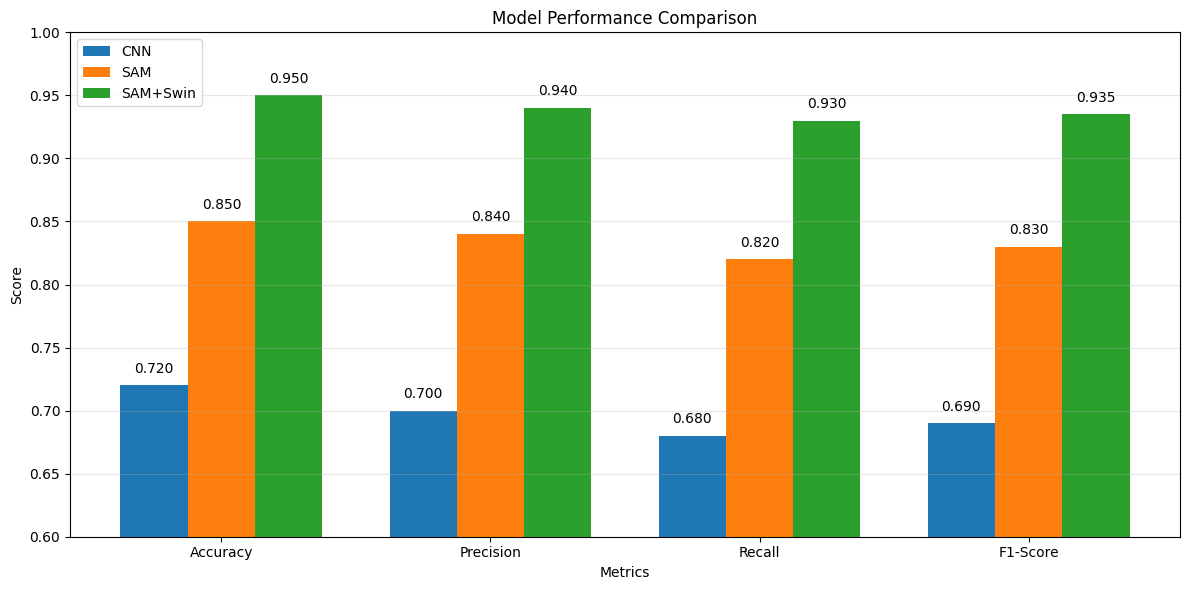

In [ ]:

# Plot: Metrics Comparison (FIXED)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = df_performance['Model'].tolist()

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    row = df_performance[df_performance['Model'] == model]
    values = row[metrics].values.flatten()

    ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)

ax.set_ylim([0.6, 1.0])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, model in enumerate(models):
    row = df_performance[df_performance['Model'] == model]
    values = row[metrics].values.flatten()

    for j, v in enumerate(values):
        ax.text(j + i * width, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()
